--- RESUMO POR GERAÇÃO ---
                n  sucesso         p    var_count  var_prop   se_prop
generacion                                                           
voto antes  18801   6269.0  0.333440  4178.666454  0.000012  0.003438
voto 2011     639    237.0  0.370892   149.098592  0.000365  0.019109
voto 2015     487    182.0  0.373717   113.983573  0.000481  0.021923
voto 2019     301    136.0  0.451827    74.551495  0.000823  0.028685


--- SUMÁRIO DO MODELO GLM ---
                 Generalized Linear Model Regression Results                  
Dep. Variable:                polintr   No. Observations:                20228
Model:                            GLM   Df Residuals:                    20220
Model Family:                Binomial   Df Model:                            7
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -12756.
Date:                Mon, 08 Jun 2026   Devianc

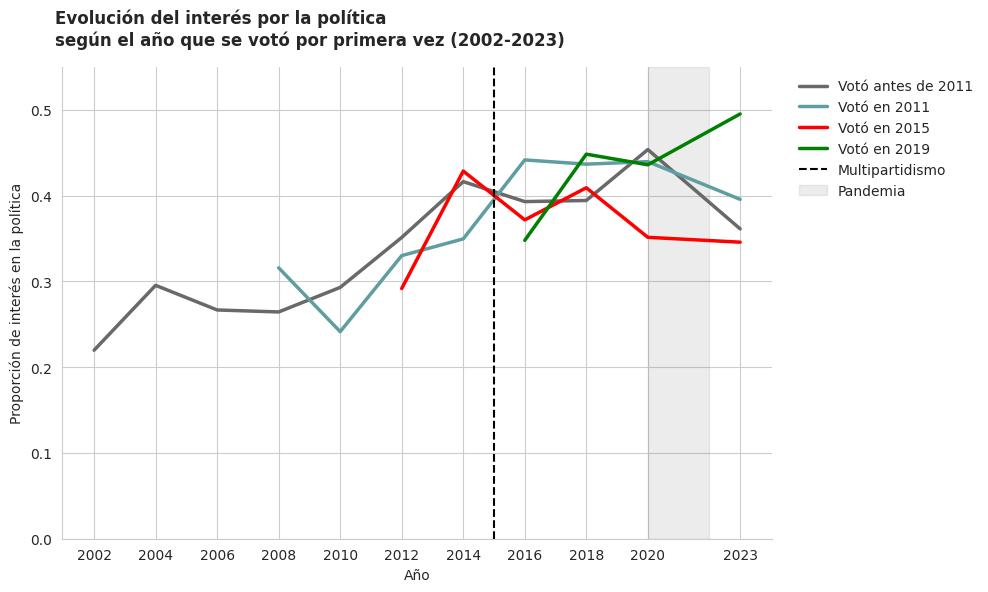

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ==============================================================================
# 1. CARGA E TRATAMENTO DOS DADOS
# ==============================================================================

dados = pd.read_csv('ESS1e06_7-ESS2e03_6-ESS3e03_7-ESS4e04_6-ESS5e03_6-ESS6e02_7-ESS7e02_3-ESS8e02_3-ESS9e03_3-ESS10SCe03_2-ESS11e04_1-subset.csv')

# Mapeamento de Rodadas para Anos Calendários
map_ano = {1: 2002, 2: 2004, 3: 2006, 4: 2008, 5: 2010,
           6: 2012, 7: 2014, 8: 2016, 9: 2018, 10: 2020, 11: 2023}

# Recodificação da variável de interesse político (binária)
map_interes = {1: 1, 2: 1, 3: 0, 4: 0, 7: None, 8: None, 9: None}

dados['ano'] = dados['essround'].map(map_ano)
dados['polintr'] = dados['polintr'].map(map_interes)

# Estimativa do ano em que completou 18 anos (ano de primeiro voto)
dados['primero'] = dados['yrbrn'] + 18

# Definição das Gerações Políticas baseadas no ano de primeiro voto
bins = [0, 2007, 2011, 2015, 2019]
labels = ['voto antes', 'voto 2011', 'voto 2015', 'voto 2019']
dados['generacion'] = pd.cut(dados['primero'], bins=bins, labels=labels, right=True)

# Filtro: Manter apenas quem já tinha idade para votar no ano da pesquisa
dados_filtrados = dados[dados['primero'] <= dados['ano']]

# Seleção de colunas e remoção de valores nulos nas variáveis chave para evitar avisos no GLM
df = dados_filtrados[['ano', 'yrbrn', 'polintr', 'generacion', 'primero']].dropna(subset=['polintr', 'generacion'])

# ==============================================================================
# 2. ANÁLISE DESCRITIVA E MODELAGEM
# ==============================================================================

# Resumo estatístico por geração
resumo = (
    df.groupby("generacion", observed=False)
      .agg(
          n=("polintr", "count"),
          sucesso=("polintr", "sum"),
          p=("polintr", "mean")
      )
)

resumo["var_count"] = resumo["n"] * resumo["p"] * (1 - resumo["p"])
resumo["var_prop"] = resumo["p"] * (1 - resumo["p"]) / resumo["n"]
resumo["se_prop"] = np.sqrt(resumo["var_prop"])

print("--- RESUMO POR GERAÇÃO ---")
print(resumo)
print("\n" + "="*60 + "\n")

# Ajuste do Modelo Linear Generalizado (GLM) - Família Binomial (Logit)
modelo = smf.glm(
    formula="polintr ~ C(generacion) * ano",
    data=df,
    family=sm.families.Binomial()
).fit(cov_type="HC1")

print("--- SUMÁRIO DO MODELO GLM ---")
print(modelo.summary())
print("\n" + "="*60 + "\n")

# ==============================================================================
# 3. VISUALIZAÇÃO GRÁFICA
# ==============================================================================

# Agrupando os dados para calcular a proporção real observada por ano e geração
df_plot = df.groupby(['ano', 'generacion'], observed=False)['polintr'].mean().reset_index()

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Paleta de cores personalizada associada rigidamente às categorias
cores = {
    'voto antes': 'dimgray',
    'voto 2011': 'cadetblue',
    'voto 2015': 'red',
    'voto 2019': 'green'
}

# Dicionário para traduzir/formatar os labels na legenda final
labels_traduzidos = {
    'voto antes': 'Votó antes de 2011',
    'voto 2011': 'Votó en 2011',
    'voto 2015': 'Votó en 2015',
    'voto 2019': 'Votó en 2019'
}

# Plot único e idiomático usando 'hue'
sns.lineplot(
    data=df_plot,
    x='ano',
    y='polintr',
    hue='generacion',
    palette=cores,
    linewidth=2.5,
    ax=ax
)

# Linha vertical indicando o Multipartidarismo
ax.axvline(
    x=2015,
    linestyle='--',
    color='black',
    linewidth=1.5,
    label='Multipartidismo'
)

# Sombra indicando o período aproximado da Pandemia
ax.axvspan(
    2020, 2022,
    color='grey',
    alpha=0.15,
    label='Pandemia'
)

# Títulos e formatação dos eixos
fig.suptitle(
    'Evolución del interés por la política\nsegún el año que se votó por primera vez (2002-2023)',
    x=0.06,
    ha='left',
    fontweight='bold'
)

ax.set_ylabel('Proporción de interés en la política')
ax.set_xlabel('Año')

# Ajuste dos ticks do eixo X para bater exatamente com os anos da pesquisa (ESS)
ax.set_xticks(sorted(df['ano'].unique()))
ax.set_ylim(0, 0.55)

# Ajuste fino da legenda externa para aplicar as traduções limpas
handles, current_labels = ax.get_legend_handles_labels()
novas_legendas = [labels_traduzidos.get(lbl, lbl) for lbl in current_labels]

ax.legend(
    handles,
    novas_legendas,
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

sns.despine()
plt.tight_layout()
plt.show()